✓ Loaded CLIP ViT-B/32 model



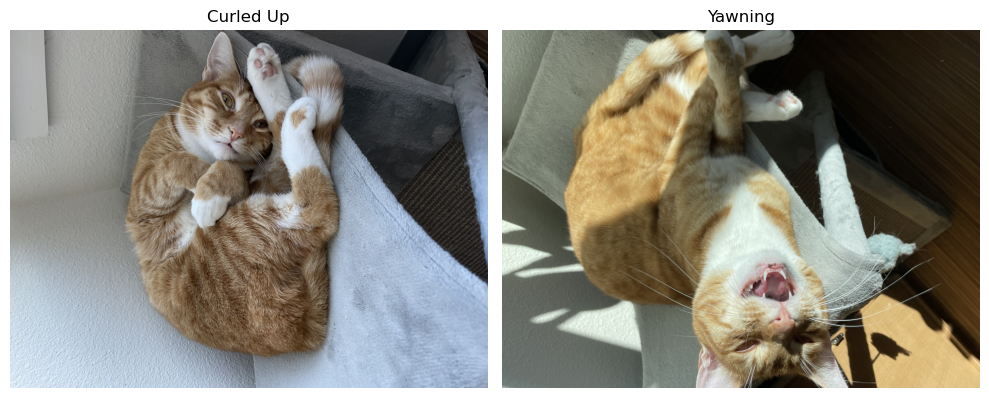


Image 1: kiki1.jpg
------------------------------------------------------------
1. a photo of a cat yawning       2.35%
2. a photo of a sleeping cat      79.18%
3. a photo of a cat sitting       17.30%
4. a photo of a dog               0.07%
5. a photo of a tiger             1.11%

Image 2: kiki2.jpg
------------------------------------------------------------
1. a photo of a cat yawning       96.92%
2. a photo of a sleeping cat      2.77%
3. a photo of a cat sitting       0.28%
4. a photo of a dog               0.00%
5. a photo of a tiger             0.03%


In [9]:
"""
CLIP Demo — Recognizing Actions and States
============================================================
This demo uses two photos of the same cat (Kiki):
1. temp_cat.jpg   → curled up (sleeping)
2. temp_cat2.jpg  → yawning
It shows how CLIP distinguishes between actions described in text.
"""

import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load Model
# ------------------------------------------------------------
model, preprocess = clip.load("ViT-B/32")
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("✓ Loaded CLIP ViT-B/32 model\n")

# ------------------------------------------------------------
# 2. Load and Display Images
# ------------------------------------------------------------
image_paths = ["kiki1.jpg", "kiki2.jpg"]
images = [Image.open(p).convert("RGB") for p in image_paths]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, img, title in zip(axes, images, ["Curled Up", "Yawning"]):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Preprocess for CLIP
image_tensors = [preprocess(img).unsqueeze(0).to(device) for img in images]

# ------------------------------------------------------------
# 3. Define Text Prompts
# ------------------------------------------------------------
text_prompts = [
    "a photo of a cat yawning",
    "a photo of a sleeping cat",
    "a photo of a cat sitting",
    "a photo of a dog",
    "a photo of a tiger"
]
text = clip.tokenize(text_prompts).to(device)

# ------------------------------------------------------------
# 4. Run CLIP on Both Images
# ------------------------------------------------------------
with torch.no_grad():
    for i, (tensor, path) in enumerate(zip(image_tensors, image_paths)):
        logits_per_image, _ = model(tensor, text)
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

        print(f"\nImage {i+1}: {path.split('/')[-1]}")
        print("------------------------------------------------------------")
        for j, prompt in enumerate(text_prompts):
            print(f"{j+1}. {prompt:<30} {probs[j]*100:.2f}%")